In [1]:
"""
Regression Loss Functions
===========================

MSE, MAE, Huber — when to use which.
"""

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print("=" * 70)
print("REGRESSION LOSSES")
print("=" * 70)

REGRESSION LOSSES


In [2]:
y_true = torch.tensor([0.0])
predictions = torch.linspace(-5, 5, 200)

mse_loss = nn.MSELoss()
mae_loss = nn.L1Loss()
huber_loss = nn.HuberLoss(delta=1.0)

mse_values = [mse_loss(p.unsqueeze(0), y_true).item() for p in predictions]
mae_values = [mae_loss(p.unsqueeze(0), y_true).item() for p in predictions]
huber_values = [huber_loss(p.unsqueeze(0), y_true).item() for p in predictions]


✓ Saved: regression_losses.png


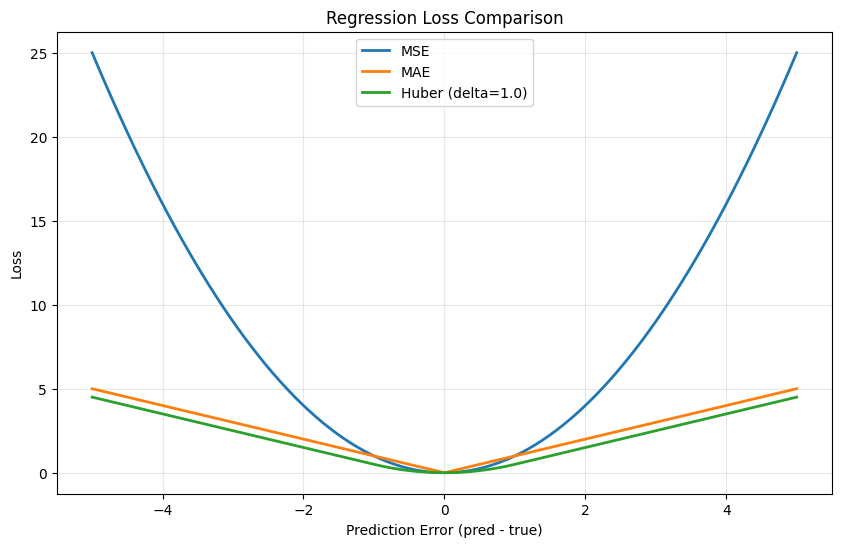

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(predictions, mse_values, label='MSE', linewidth=2)
plt.plot(predictions, mae_values, label='MAE', linewidth=2)
plt.plot(predictions, huber_values, label='Huber (delta=1.0)', linewidth=2)
plt.xlabel('Prediction Error (pred - true)')
plt.ylabel('Loss')
plt.title('Regression Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('regression_losses.png', dpi=150)
print("✓ Saved: regression_losses.png")
plt.show()

In [4]:
print("""
MSE (Mean Squared Error):
  Loss = (pred - true)^2
  ✓ Use when: outliers ARE meaningful errors you want to punish hard
  ✗ Avoid when: dataset has noisy outliers you don't want to overreact to
  Behavior: grows QUADRATICALLY — a prediction off by 10 is punished 
            100x more than off by 1 (not 10x)

MAE (Mean Absolute Error):
  Loss = |pred - true|
  ✓ Use when: outliers are likely noise, want robust/stable training
  ✗ Avoid when: you specifically care about penalizing large errors more
  Behavior: grows LINEARLY — off by 10 is punished exactly 10x more than off by 1

Huber Loss:
  Behaves like MSE for SMALL errors (< delta), like MAE for LARGE errors
  ✓ Use when: want MSE's smoothness near zero, but MAE's robustness to outliers
  This is the "best of both" — used often in practice, e.g. bounding box 
  regression in object detection
""")


MSE (Mean Squared Error):
  Loss = (pred - true)^2
  ✓ Use when: outliers ARE meaningful errors you want to punish hard
  ✗ Avoid when: dataset has noisy outliers you don't want to overreact to
  Behavior: grows QUADRATICALLY — a prediction off by 10 is punished 
            100x more than off by 1 (not 10x)

MAE (Mean Absolute Error):
  Loss = |pred - true|
  ✓ Use when: outliers are likely noise, want robust/stable training
  ✗ Avoid when: you specifically care about penalizing large errors more
  Behavior: grows LINEARLY — off by 10 is punished exactly 10x more than off by 1

Huber Loss:
  Behaves like MSE for SMALL errors (< delta), like MAE for LARGE errors
  ✓ Use when: want MSE's smoothness near zero, but MAE's robustness to outliers
  This is the "best of both" — used often in practice, e.g. bounding box 
  regression in object detection

